In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("supply_chain_data.csv")

print(df.head())
print(df.info())

  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai        29          

In [3]:
#Data Cleaning
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna(0, inplace=True)

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64


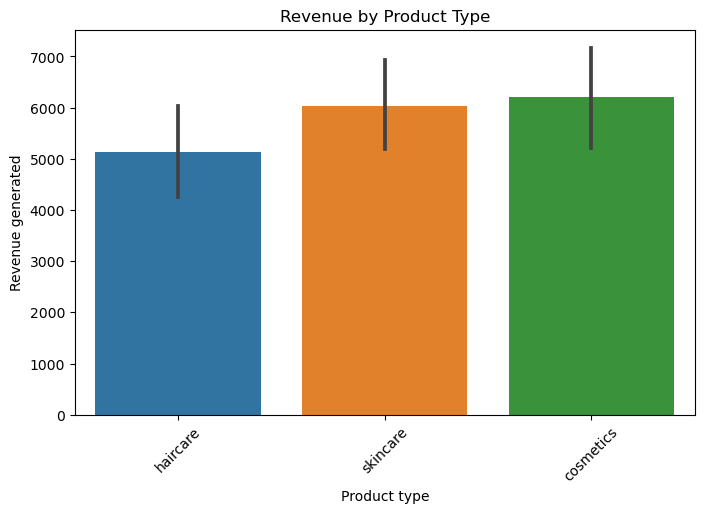

In [4]:
#Exploratory Data Analysis
#Revenue by Product Type

plt.figure(figsize=(8,5))
sns.barplot(x='Product type', y='Revenue generated', data=df)
plt.title("Revenue by Product Type")
plt.xticks(rotation=45)
plt.show()

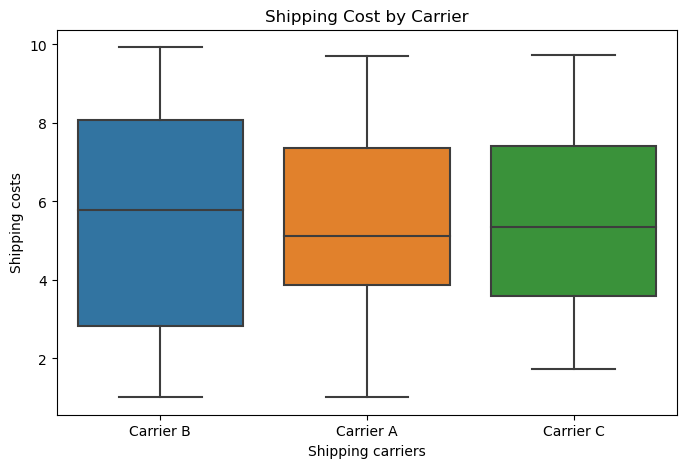

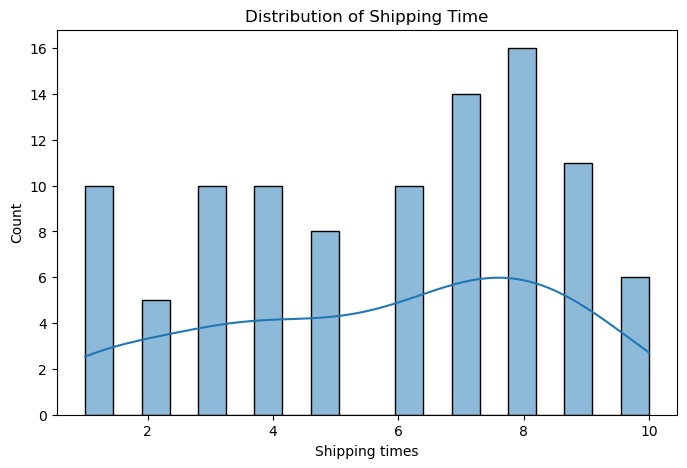

Total Revenue: 577604.8187380086
Average Shipping Cost: 5.548149072019588


In [7]:
#Shipping Cost Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x='Shipping carriers', y='Shipping costs', data=df)
plt.title("Shipping Cost by Carrier")
plt.show()

#Delivery Time Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['Shipping times'], bins=20, kde=True)
plt.title("Distribution of Shipping Time")
plt.show()

#KPI Analysis
total_revenue = df['Revenue generated'].sum()
avg_shipping_cost = df['Shipping costs'].mean()

print("Total Revenue:", total_revenue)
print("Average Shipping Cost:", avg_shipping_cost)

In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit prophet openpyxl

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Obtaining dependency information for prophet from https://files.pythonhosted.org/packages/d9/9c/af59d9f30e9e72f2b36bd578a47a84c8fbf7f72c2d9771ef40ef16fb36eb/prophet-1.3.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for cmdstanpy>=1.0.4 from https://files.pythonhosted.org/packages/ef/04/7bbe85aa6abf99236cc657ceb5a629f63a82a01910a095533111ea3860f3/cmdstanpy-1.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for holidays<1,>=0.25 from https://files.pythonhosted.org/packages/b9/54/7947b0cba0c91b81801da793ea2d273aab5bdd5484a5ba6c2d3863110f07/holidays-0.97-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/53.0 kB ? eta -:--:--
     ---------------------------------------- 53.0/53.0 kB 2.9 MB/s eta 0:00:00
  Obtaining dependency information for importlib_resources from https://files.py

DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.41 requires requests_mock, which is not installed.
conda-repo-cli 1.0.41 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.41 requires nbformat==5.4.0, but you have nbformat 5.7.0 which is incompatible.
conda-repo-cli 1.0.41 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
conda-repo-cli 1.0.41 requires requests==2.28.1, but you have requests 2.31.0 which is incompatible.


In [9]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [19]:
#Machine Learning Prediction

X = df[['Price', 'Availability', 'Number of products sold',
        'Shipping costs']]

y = df['Revenue generated']

#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train ML Model
model = RandomForestRegressor()

model.fit(X_train, y_train)

#Predictions
predictions = model.predict(X_test)

print(predictions[:5])

#Accuracy Check
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

#Feature
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

[4331.53524822 5580.65584484 5730.17215389 6926.39193899 4150.59463614]
Mean Absolute Error: 2657.487805447992
R2 Score: -0.07467708400082929
                   Feature  Importance
1             Availability    0.278341
2  Number of products sold    0.270300
3           Shipping costs    0.258361
0                    Price    0.192997


In [20]:
#Demand Forecasting
#Using Time Series Forecasting
#Install Prophet

pip install prophet


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


21:19:02 - cmdstanpy - INFO - Chain [1] start processing
21:19:04 - cmdstanpy - INFO - Chain [1] done processing


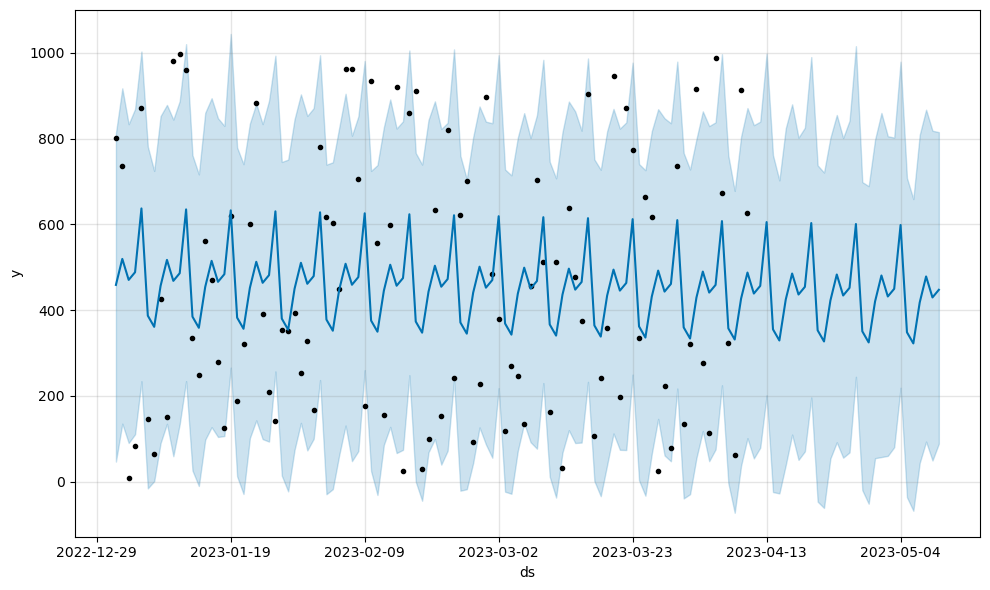

In [21]:
#Forecasting Code
from prophet import Prophet

# Create sample date column
df['Date'] = pd.date_range(
    start='2023-01-01',
    periods=len(df),
    freq='D'
)

forecast_df = df[['Date', 'Number of products sold']]
forecast_df.columns = ['ds', 'y']

# Create model
model = Prophet()

# Train model
model.fit(forecast_df)

# Future dates
future = model.make_future_dataframe(periods=30)

# Forecast
forecast = model.predict(future)

# Show results
model.plot(forecast)
plt.show()

In [22]:
df.to_excel("SupplyChain_Cleaned_Data.xlsx", index=False)